# Protein Prediction: Setup And Exploration

Use the `Protein Prediction (UdonPred uv)` kernel. This notebook is for quick setup checks, small UdonPred inference runs, and first TriZOD score exploration.

## 1. Check Environment

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "UdonPred").exists():
    ROOT = ROOT.parent

print("Python:", sys.version)
print("Project root:", ROOT)
print("UdonPred exists:", (ROOT / "UdonPred").exists())
print("TriZOD exists:", (ROOT / "TriZOD").exists())

Python: 3.13.9 (v3.13.9:8183fa5e3f7, Oct 14 2025, 10:27:13) [Clang 16.0.0 (clang-1600.0.26.6)]
Project root: /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction
UdonPred exists: True
TriZOD exists: True


In [2]:
import importlib

modules = [
    "Bio",
    "datasets",
    "onnxruntime",
    "torch",
    "transformers",
    "pandas",
    "polars",
    "sklearn",
    "scipy",
    "yaml",
]

for name in modules:
    module = importlib.import_module(name)
    print(f"{name}: OK {getattr(module, '__version__', '')}")

Bio: OK 1.87
datasets: OK 4.8.4
onnxruntime: OK 1.25.0
torch: OK 2.11.0
transformers: OK 4.54.0
pandas: OK 3.0.2
polars: OK 1.40.1
sklearn: OK 1.8.0
scipy: OK 1.17.1
yaml: OK 6.0.3


## 2. Run A Small UdonPred Prediction

The first run may take several minutes because it downloads the ProstT5 backbone from Hugging Face.

In [3]:
import subprocess

cmd = [
    sys.executable,
    "predict.py",
    str(ROOT / "examples" / "smoke.fasta"),
    "weights",
    "--target",
    "trizod",
    "--device",
    "cpu",
    "--batch-size",
    "200",
    "--smooth",
    "0",
]

result = subprocess.run(
    cmd,
    cwd=ROOT / "UdonPred",
    text=True,
    capture_output=True,
    timeout=900,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
result.check_returncode()

Loading tokenizer (Rostlab/ProstT5_fp16) ...
Loading backbone (Rostlab/ProstT5_fp16) ...
Loading head (weights/trizod.onnx) ...
>smoke
1	M	0.382	
2	K	0.267	
3	T	0.370	
4	A	0.330	
5	Y	0.230	
6	I	0.123	
7	A	0.303	
8	K	0.304	
9	Q	0.305	
10	R	0.269	
11	Q	0.449	
12	I	0.274	
13	S	0.296	
14	F	0.401	
15	V	0.371	
16	K	0.305	
17	S	0.291	
18	H	0.306	
19	F	0.244	
20	S	0.109	
21	R	0.149	
22	Q	0.163	
23	D	0.196	
24	I	0.155	
25	L	0.089	
26	D	0.126	
27	L	0.165	
28	W	0.179	
29	I	0.084	
30	Y	0.111	
31	H	0.171	
32	T	0.227	
33	Q	0.230	
34	G	0.325	
35	Y	0.454	
36	F	0.389	
37	P	0.299	



## 3. Inspect Available TriZOD Files

In [4]:
trizod_dir = ROOT / "TriZOD"
for path in sorted(trizod_dir.glob("*")):
    print(path.name)

CheZOD117_test_set.fasta
CheZOD117_test_set_clu.tsv
TriZOD_test_set.fasta
TriZOD_test_set_clu.tsv
moderate.json
moderate_rest_clu.tsv
moderate_rest_set.fasta
strict.json
strict_rest_clu.tsv
strict_rest_set.fasta
tolerant.json
tolerant_rest_clu.tsv
tolerant_rest_set.fasta
unfiltered.json
unfiltered_rest_clu.tsv
unfiltered_rest_set.fasta


## 4. Load TriZOD JSONL Files

The TriZOD files use newline-delimited JSON records, despite the `.json` extension. This cell loads each tier and shows the record shape so the group can agree on the parsing code before deeper analysis.

In [5]:
import json
import pandas as pd

def read_jsonl(path):
    with path.open() as handle:
        return [json.loads(line) for line in handle if line.strip()]

tiers = ["unfiltered", "tolerant", "moderate", "strict"]
records = []

for tier in tiers:
    path = trizod_dir / f"{tier}.json"
    if not path.exists():
        continue
    data = read_jsonl(path)
    first = data[0] if data else {}
    records.append({
        "tier": tier,
        "records": len(data),
        "columns": list(first.keys()) if isinstance(first, dict) else [],
        "first_id": first.get("ID") if isinstance(first, dict) else None,
        "first_sequence_length": len(first.get("seq", "")) if isinstance(first, dict) else None,
    })

pd.DataFrame(records)

,tier,records,columns,first_id,first_sequence_length
0,unfiltered,15324,"[ID, entryID, stID, entity_assemID, entityID, ...",36025_1_1_1,25
1,tolerant,14147,"[ID, entryID, stID, entity_assemID, entityID, ...",36025_1_1_1,25
2,moderate,10155,"[ID, entryID, stID, entity_assemID, entityID, ...",19347_1_1_1,140
3,strict,1914,"[ID, entryID, stID, entity_assemID, entityID, ...",19347_1_1_1,140


## 5. Plot G-Score Distributions

Each TriZOD record has a `gscores` list with one value per residue, plus `None` where no score is available.

                count      mean       std  min     25%     50%     75%     max
tier                                                                          
moderate    1012958.0  0.163114  0.229141  0.0  0.0452  0.0772  0.1392  1.0000
strict       209521.0  0.163294  0.230421  0.0  0.0461  0.0767  0.1367  0.9995
tolerant    1329342.0  0.179254  0.245705  0.0  0.0455  0.0807  0.1580  1.0000
unfiltered  1400447.0  0.181758  0.247591  0.0  0.0456  0.0812  0.1612  1.0000


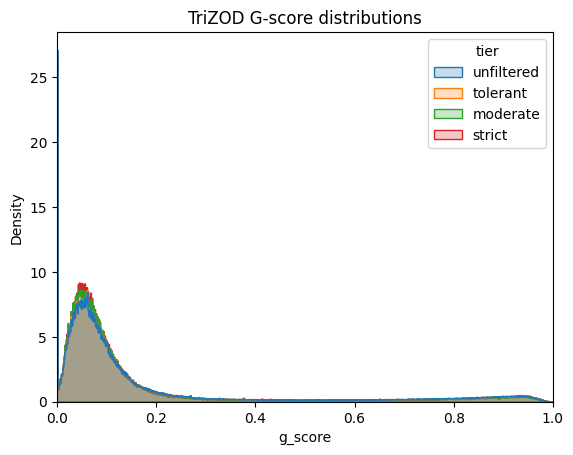

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

rows = []
for tier in tiers:
    path = trizod_dir / f"{tier}.json"
    if not path.exists():
        continue
    for record in read_jsonl(path):
        for position, score in enumerate(record.get("gscores", []), start=1):
            if score is not None and 0 <= score <= 1:
                rows.append({
                    "tier": tier,
                    "id": record.get("ID"),
                    "entry_id": record.get("entryID"),
                    "position": position,
                    "g_score": float(score),
                })

gscore_df = pd.DataFrame(rows)
print(gscore_df.groupby("tier")["g_score"].describe() if not gscore_df.empty else "No G-scores found")

if not gscore_df.empty:
    sns.histplot(data=gscore_df, x="g_score", hue="tier", element="step", stat="density", common_norm=False)
    plt.xlim(0, 1)
    plt.title("TriZOD G-score distributions")
    plt.show()

## 6. Compare TriZOD Filtering Tiers

Compare unfiltered, tolerant, moderate, and strict TriZOD G-score distributions and overlap. This is useful for understanding how filtering changes the available data and score distribution.

In [7]:
trizod_records = {}
for tier in tiers:
    path = trizod_dir / f"{tier}.json"
    trizod_records[tier] = read_jsonl(path) if path.exists() else []

tier_summary_rows = []
for tier, records_for_tier in trizod_records.items():
    scored_residues = 0
    total_residues = 0
    protein_ids = set()
    entry_ids = set()
    for record in records_for_tier:
        protein_ids.add(record.get("ID"))
        entry_ids.add(record.get("entryID"))
        total_residues += len(record.get("seq", ""))
        scored_residues += sum(score is not None for score in record.get("gscores", []))
    tier_summary_rows.append({
        "tier": tier,
        "records": len(records_for_tier),
        "unique_entry_ids": len(entry_ids),
        "unique_record_ids": len(protein_ids),
        "total_residues": total_residues,
        "scored_residues": scored_residues,
        "scored_fraction": scored_residues / total_residues if total_residues else 0,
    })

tier_summary_df = pd.DataFrame(tier_summary_rows)
display(tier_summary_df)

,tier,records,unique_entry_ids,unique_record_ids,total_residues,scored_residues,scored_fraction
0,unfiltered,15324,13740,15324,1583410,1400447,0.884450
1,tolerant,14147,12747,14147,1475465,1329342,0.900965
2,moderate,10155,9523,10155,1068859,1012958,0.947700
3,strict,1914,1795,1914,218024,209521,0.961000


In [8]:
gscore_by_tier = {}
for tier, records_for_tier in trizod_records.items():
    values = []
    for record in records_for_tier:
        values.extend(score for score in record.get("gscores", []) if score is not None)
    gscore_by_tier[tier] = pd.Series(values, name=tier, dtype="float64")

gscore_summary_df = pd.DataFrame({
    tier: series.describe()
    for tier, series in gscore_by_tier.items()
}).T
display(gscore_summary_df.style.format("{:.4f}"))

,count,mean,std,min,25%,50%,75%,max
unfiltered,1400447.0000,0.1818,0.2476,0.0000,0.0456,0.0812,0.1612,1.0000
tolerant,1329342.0000,0.1793,0.2457,0.0000,0.0455,0.0807,0.1580,1.0000
moderate,1012958.0000,0.1631,0.2291,0.0000,0.0452,0.0772,0.1392,1.0000
strict,209521.0000,0.1633,0.2304,0.0000,0.0461,0.0767,0.1367,0.9995


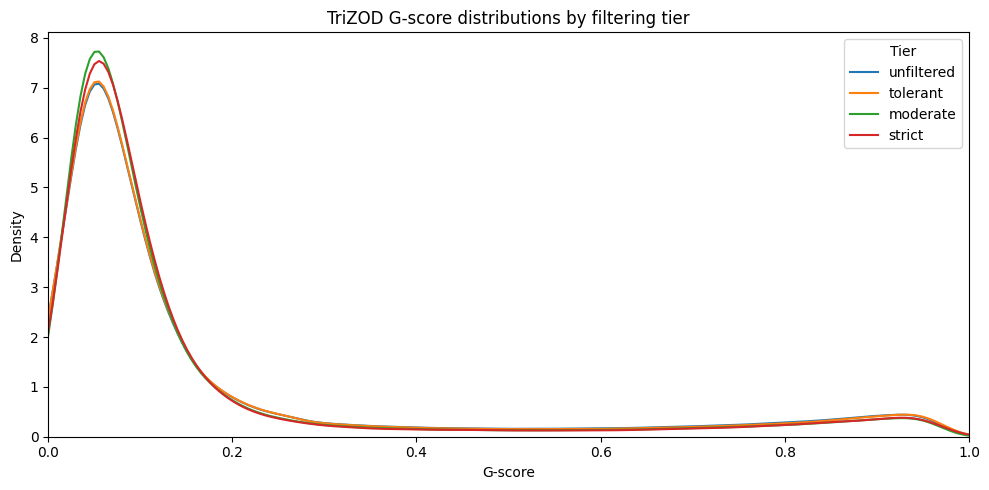

In [9]:
plt.figure(figsize=(10, 5))
for tier, series in gscore_by_tier.items():
    sns.kdeplot(series, label=tier, clip=(0, 1), common_norm=False)
plt.xlim(0, 1)
plt.xlabel("G-score")
plt.ylabel("Density")
plt.title("TriZOD G-score distributions by filtering tier")
plt.legend(title="Tier")
plt.tight_layout()
plt.show()

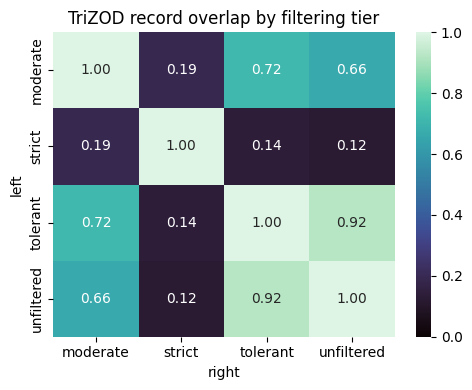

right,moderate,strict,tolerant,unfiltered
left,,,,
moderate,10155,1914,10155,10155
strict,1914,1914,1914,1914
tolerant,10155,1914,14147,14147
unfiltered,10155,1914,14147,15324


In [10]:
id_sets = {
    tier: {record.get("ID") for record in records_for_tier}
    for tier, records_for_tier in trizod_records.items()
}

overlap_rows = []
for left in tiers:
    for right in tiers:
        left_ids = id_sets.get(left, set())
        right_ids = id_sets.get(right, set())
        intersection = left_ids & right_ids
        union = left_ids | right_ids
        overlap_rows.append({
            "left": left,
            "right": right,
            "shared_records": len(intersection),
            "jaccard": len(intersection) / len(union) if union else 0,
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_matrix = overlap_df.pivot(index="left", columns="right", values="jaccard")

plt.figure(figsize=(5, 4))
sns.heatmap(overlap_matrix, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1)
plt.title("TriZOD record overlap by filtering tier")
plt.tight_layout()
plt.show()

display(overlap_df.pivot(index="left", columns="right", values="shared_records"))

In [11]:
def record_score_frame(tier, records_for_tier):
    rows = []
    for record in records_for_tier:
        record_id = record.get("ID")
        for position, score in enumerate(record.get("gscores", []), start=1):
            if score is not None:
                rows.append({"ID": record_id, "position": position, tier: float(score)})
    return pd.DataFrame(rows)

tier_score_frames = {
    tier: record_score_frame(tier, records_for_tier)
    for tier, records_for_tier in trizod_records.items()
}

comparison_pairs = [("unfiltered", "tolerant"), ("tolerant", "moderate"), ("moderate", "strict"), ("unfiltered", "strict")]
difference_rows = []

for left, right in comparison_pairs:
    left_df = tier_score_frames[left]
    right_df = tier_score_frames[right]
    merged = left_df.merge(right_df, on=["ID", "position"], how="inner")
    diff = merged[right] - merged[left]
    difference_rows.append({
        "comparison": f"{right} - {left}",
        "shared_scored_residues": len(merged),
        "mean_difference": diff.mean() if len(diff) else None,
        "median_abs_difference": diff.abs().median() if len(diff) else None,
        "max_abs_difference": diff.abs().max() if len(diff) else None,
        "correlation": merged[left].corr(merged[right], method="spearman") if len(merged) else None,
    })

tier_difference_df = pd.DataFrame(difference_rows)
display(tier_difference_df.style.format({
    "mean_difference": "{:.4f}",
    "median_abs_difference": "{:.4f}",
    "max_abs_difference": "{:.4f}",
    "correlation": "{:.4f}",
}))

,comparison,shared_scored_residues,mean_difference,median_abs_difference,max_abs_difference,correlation
0,tolerant - unfiltered,1329342,0.0004,0.0000,0.7966,0.9898
1,moderate - tolerant,1012958,0.0000,0.0000,0.0000,1.0000
2,strict - moderate,209521,0.0000,0.0000,0.0000,1.0000
3,strict - unfiltered,209521,0.0000,0.0000,0.0000,1.0000


## 7. Check UdonPred Evaluation Data

The 7x7 matrix needs `test.fasta` and `test.jsonl` for each UdonPred dataset.

In [12]:
DATASETS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]

rows = []
for dataset in DATASETS:
    dataset_dir = ROOT / "UdonPred" / "data" / dataset
    test_fasta = dataset_dir / "test.fasta"
    test_jsonl = dataset_dir / "test.jsonl"
    rows.append({
        "dataset": dataset,
        "test_fasta": test_fasta.exists(),
        "test_jsonl": test_jsonl.exists(),
        "jsonl_records": sum(1 for _ in test_jsonl.open()) if test_jsonl.exists() else 0,
        "fasta_headers": sum(1 for line in test_fasta.open() if line.startswith(">")) if test_fasta.exists() else 0,
    })

data_check_df = pd.DataFrame(rows)
display(data_check_df)
assert data_check_df[["test_fasta", "test_jsonl"]].all().all(), "Missing one or more UdonPred test files."

,dataset,test_fasta,test_jsonl,jsonl_records,fasta_headers
0,trizod,True,True,348,348
1,chezod,True,True,117,117
2,softdis,True,True,1869,1869
3,pdbflex,True,True,1319,1319
4,atlas,True,True,140,140
5,plddt,True,True,265,265
6,disprot,True,True,319,319


## 8. Run The 7x7 Matrix

This launches 49 prediction jobs. On CPU, it can take many hours because ProstT5 embeddings are computed for every test set. Set `RUN_FULL_MATRIX = True` when you are ready to run it. Use `DEVICE = "cuda"` on a GPU machine.

In [23]:
import subprocess

RUN_FULL_MATRIX = True
DEVICE = "cpu"  # change to "cuda" on a GPU machine

matrix_cmd = [
    sys.executable,
    str(ROOT / "scripts" / "run_udonpred_matrix.py"),
    "--device",
    DEVICE,
]

print(" ".join(matrix_cmd))

if RUN_FULL_MATRIX:
    subprocess.run(matrix_cmd, cwd=ROOT, check=True)
else:
    print("Skipped. Set RUN_FULL_MATRIX = True to start the full 7x7 run.")

/Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/UdonPred/.venv/bin/python /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/scripts/run_udonpred_matrix.py --device cpu
Skipping existing predictions: /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/results/udonpred_matrix/predictions/trizod_trizod
Skipping existing predictions: /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/results/udonpred_matrix/predictions/trizod_chezod
Skipping existing predictions: /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/results/udonpred_matrix/predictions/trizod_softdis
Skipping existing predictions: /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/results/udonpred_matrix/predictions/trizod_pdbflex
Skipping existing predictions: /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/result

If prediction files already exist and you only want to recompute metrics, run this cell.

In [24]:
RECOMPUTE_METRICS_ONLY = True

metrics_cmd = [
    sys.executable,
    str(ROOT / "scripts" / "run_udonpred_matrix.py"),
    "--skip-predictions",
]

print(" ".join(metrics_cmd))

if RECOMPUTE_METRICS_ONLY:
    subprocess.run(metrics_cmd, cwd=ROOT, check=True)
else:
    print("Skipped. Set RECOMPUTE_METRICS_ONLY = True after predictions exist.")

/Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/UdonPred/.venv/bin/python /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/scripts/run_udonpred_matrix.py --skip-predictions
Wrote /Users/kathi/Desktop/Uni/Master_Semester_3/Protein Prediction/Protein_Prediction/results/udonpred_matrix/matrix.csv


## 9. Evaluate Matrix Results

The matrix uses Spearman correlation for continuous test sets. For DisProt, it reports average precision and AUROC.

In [25]:
matrix_path = ROOT / "results" / "udonpred_matrix" / "matrix.csv"

if not matrix_path.exists():
    raise FileNotFoundError(
        f"Matrix file not found: {matrix_path}\n"
        "Run the full matrix cell first, or run `python scripts/run_udonpred_matrix.py --device cpu` from the repo root."
    )

matrix_df = pd.read_csv(matrix_path).set_index("train_dataset")
matrix_numeric = matrix_df.apply(pd.to_numeric)
display(matrix_numeric.style.format("{:.3f}"))

,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
train_dataset,,,,,,,,
trizod,0.508,0.708,0.257,-0.006,0.413,0.719,0.899,0.930
chezod,0.486,0.691,0.235,-0.039,0.327,0.713,0.890,0.925
softdis,0.470,0.537,0.500,0.150,0.597,0.784,0.872,0.918
pdbflex,0.287,0.286,0.292,0.395,0.349,0.520,0.519,0.737
atlas,0.400,0.595,0.310,0.056,0.708,0.719,0.870,0.920
plddt,0.423,0.625,0.284,0.104,0.512,0.839,0.875,0.927
disprot,0.364,0.663,0.255,0.099,0.624,0.774,0.935,0.959


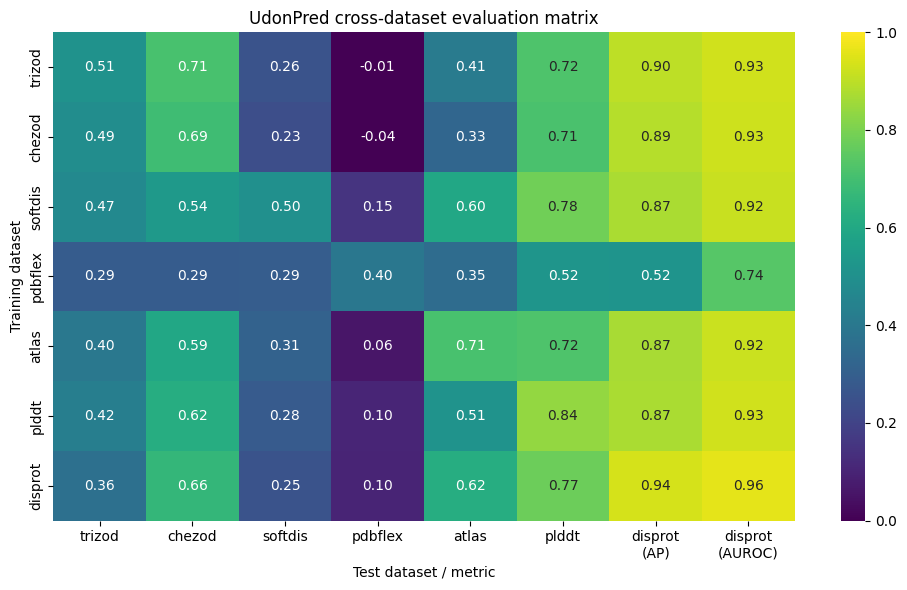

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(matrix_numeric, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Test dataset / metric")
plt.ylabel("Training dataset")
plt.title("UdonPred cross-dataset evaluation matrix")
plt.tight_layout()
plt.savefig(ROOT / "results" / "udonpred_matrix" / "matrix_heatmap.png")
plt.show()

In [27]:
continuous_tests = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt"]

best_rows = []
for test_dataset in continuous_tests + ["disprot\n(AP)", "disprot\n(AUROC)"]:
    best_train = matrix_numeric[test_dataset].idxmax()
    best_score = matrix_numeric.loc[best_train, test_dataset]
    diagonal_score = matrix_numeric.loc[test_dataset, test_dataset] if test_dataset in matrix_numeric.index else None
    best_rows.append({
        "test_metric": test_dataset,
        "best_training_dataset": best_train,
        "best_score": best_score,
        "same_dataset_score": diagonal_score,
        "headroom_vs_same_dataset": best_score - diagonal_score if diagonal_score is not None else None,
    })

evaluation_summary_df = pd.DataFrame(best_rows)
display(evaluation_summary_df.style.format({
    "best_score": "{:.3f}",
    "same_dataset_score": "{:.3f}",
    "headroom_vs_same_dataset": "{:.3f}",
}))

,test_metric,best_training_dataset,best_score,same_dataset_score,headroom_vs_same_dataset
0,trizod,trizod,0.508,0.508,0.000
1,chezod,trizod,0.708,0.691,0.017
2,softdis,softdis,0.500,0.500,0.000
3,pdbflex,pdbflex,0.395,0.395,0.000
4,atlas,atlas,0.708,0.708,0.000
5,plddt,plddt,0.839,0.839,0.000
6,disprot (AP),disprot,0.935,nan,nan
7,disprot (AUROC),disprot,0.959,nan,nan


In [28]:
diagonal = pd.Series(
    {dataset: matrix_numeric.loc[dataset, dataset] for dataset in continuous_tests},
    name="same_dataset_spearman",
)

off_diagonal_values = []
for train_dataset in continuous_tests:
    for test_dataset in continuous_tests:
        if train_dataset != test_dataset:
            off_diagonal_values.append(matrix_numeric.loc[train_dataset, test_dataset])

print("Mean same-dataset Spearman:", round(diagonal.mean(), 3))
print("Mean cross-dataset Spearman:", round(pd.Series(off_diagonal_values).mean(), 3))
display(diagonal.to_frame())

Mean same-dataset Spearman: 0.607
Mean cross-dataset Spearman: 0.404


,same_dataset_spearman
trizod,0.507853
chezod,0.691124
softdis,0.499879
pdbflex,0.395383
atlas,0.708063
plddt,0.838924


## 10. Next Project Tasks

- Build null baselines with shuffled labels.
- Compare simple ensemble strategies across predictors.
- Use the matrix summary to decide which dataset definitions transfer well and which ones disagree.